# MODELADO - EVALUACIÓN

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, recall_score, f1_score, precision_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [ ]:
#matrix confusion
def matriz_confusion(modelo, X_test, y_test):
     #Predicciones
    y_pred = modelo.predict(X_test)

    #Matriz de confusión
    cm = confusion_matrix(y_true=y_test, y_pred=y_pred, labels=None, normalize=None)

    #Etiquetas de las clases
    class_names = ['No Acepta TC', 'Acepta TC']

    #Crear figura y ejes
    fig, ax = plt.subplots()

    #Crear el mapa de calor
    heatmap = sns.heatmap(cm, cmap="Blues", annot=True, fmt="d", cbar=False,
                          xticklabels=class_names, yticklabels=class_names,
                          linewidths=0.5, linecolor='gray', ax=ax)

    #Añadir etiquetas a los ejes
    ax.set_xlabel('Predicciones del Modelo')
    ax.set_ylabel('Valores Reales')
    ax.set_title('Matriz de Confusión')

    #Ajustar la figura
    plt.tight_layout()

    #Mostrar la figura
    plt.show()

In [ ]:
#models evaluation
def evaluation_metrics(grid_search):
    medidas = pd.DataFrame(index=['roc_auc de la CV', 'precision de la CV', 'recall de la CV', 'accuracy de la CV', 'f1 de la CV'])
    medidas['Mejor_Modelo'] = [grid_search.cv_results_['mean_test_roc_auc'][grid_search.best_index_], 
                      grid_search.cv_results_['mean_test_precision'][grid_search.best_index_],
                      grid_search.cv_results_['mean_test_recall'][grid_search.best_index_],
                      grid_search.cv_results_['mean_test_accuracy'][grid_search.best_index_],
                      grid_search.cv_results_['mean_test_f1'][grid_search.best_index_]]
    medidas.sort_values(by='Mejor_Modelo', ascending=False, inplace=True)
    return medidas

In [ ]:
#load train data
train= pd.read_csv('Data/processed/train_processed.csv')
train

,cat__tipo_trabajo_Vive de los arriendos,cat__tipo_trabajo_administrador negocio,cat__tipo_trabajo_ama de casa,cat__tipo_trabajo_desempleado,cat__tipo_trabajo_empleado,cat__tipo_trabajo_emprendedor,cat__tipo_trabajo_estudiante,cat__tipo_trabajo_pensionado,cat__tipo_trabajo_servicios,cat__tipo_trabajo_tecnico,...,num__edad,num__campana,num__dias_ultima_camp,num__no_contactos,num__emp_var_rate,num__cons_price_idx,num__cons_conf_idx,num__euribor3m,num__nr_employed,num__y
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.506494,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.246753,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.285714,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.493506,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.090909,0.00000,1.000000,0.000000,0.937500,0.991835,0.60251,0.962728,0.859848,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23094,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.142857,0.00000,0.009009,0.166667,0.479167,1.000000,0.00000,0.203608,0.000000,0.0
23095,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.363636,0.00000,1.000000,0.000000,0.479167,1.000000,0.00000,0.203608,0.000000,0.0
23096,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.493506,0.02439,1.000000,0.000000,0.479167,1.000000,0.00000,0.203608,0.000000,0.0
23097,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.337662,0.00000,1.000000,0.000000,0.479167,1.000000,0.00000,0.203608,0.000000,1.0


In [ ]:
#feactures
X= train.drop("num__y", axis=1)
#target
y= train["num__y"]
#data split
X_train, X_test, Y_train, Y_test= train_test_split(X, y, test_size=0.25, random_state=0, shuffle= True, stratify=None) 

### Modelo 1

#### Regresión Logística

In [ ]:
from sklearn.linear_model import LogisticRegression

Entrenamiento

In [ ]:
#Regresión
modelRegression= LogisticRegression()

#Hiperparámetros
params = {
    'class_weight': [None, 'balanced', [{0: 1, 1: w} for w in np.arange(1, 5)]],  #Manejar clases desbalanceadas
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],  #Algoritmo a utilizar en la optimización
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  #Tipo de regularización
    'max_iter': [100, 500, 1000]  #Número de iteraciones
}

#Métricas a utilizar
scoring= ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

#Grid
grid_search= GridSearchCV(modelRegression, params, scoring= scoring, refit='recall', n_jobs=-1, cv=10)
grid_search.fit(X_train, Y_train) #70%

#Mejor modelo e hiperparametros
best_regression= grid_search.best_estimator_

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means t

In [ ]:
#Mejor modelo e hiperparametros
best_regression

LogisticRegression(class_weight='balanced', max_iter=1000, penalty='none',
                   solver='sag')

In [ ]:
#Mejores párametros
grid_search.best_params_

{'class_weight': 'balanced',
 'max_iter': 1000,
 'penalty': 'none',
 'solver': 'sag'}

Parámetros:
- class_weight: asigna pesos diferentes a las clases en función de su frecuencia en los datos. 
- solver: algoritmo que se utiliza para resolver el problema de optimización de la regresión logística.
- penalty: norma que se utiliza para regularizar el modelo.
- max_iter: número máximo de iteraciones permitidas para que el modelo converja.

Evaluación de desempeño del modelo con los datos de entrenamiento

In [ ]:
#Medida de evaluación del mejor modelo - entranamiento (train)
evaluation_metrics(grid_search)

,Mejor_Modelo
roc_auc de la CV,0.751951
recall de la CV,0.693985
accuracy de la CV,0.651546
f1 de la CV,0.331648
precision de la CV,0.230667


Evaluación

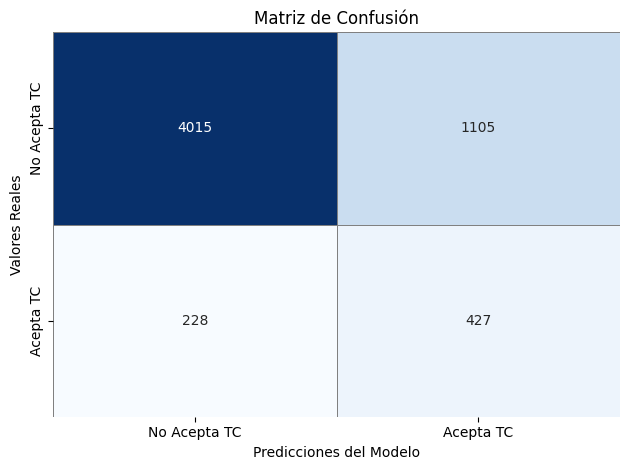

In [ ]:
#Matriz de confusión
matriz_confusion(best_regression, X_test, Y_test)

Evaluación de desempeño del modelo con los datos de prueba

In [ ]:
#Predecir resultados para datos de prueba
y_pred= best_regression.predict(X_test)

In [ ]:
print("Accuracy %s \n" %balanced_accuracy_score(Y_test, y_pred))
print("Roc %s \n" %roc_auc_score(Y_test, y_pred))
print("Recall %s \n" %recall_score(Y_test, y_pred))
print("F1 Score %s \n" %f1_score(Y_test, y_pred, average="binary"))
print("Precision %s \n" %precision_score(Y_test, y_pred))

Accuracy 0.7180440422232824 

Roc 0.7180440422232824 

Recall 0.6519083969465649 

F1 Score 0.39048925468678547 

Precision 0.27872062663185376 



- El modelo es capaz de 
- El modelo es capaz de 
- El modelo es capaz de 
- El modelo es capaz de 
- El modelo es capaz de 

Conclusión:


### Modelo 2

#### Árbol de decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier

Entrenamiento

In [ ]:
#Árbol
modelTree= DecisionTreeClassifier()

#Hiperparámetros
params= {
    'criterion': ['gini', 'entropy'], #Indice de información 
    'max_depth': [4,8,12,18], #Niveles de profundidad
    'class_weight': [{0: 1, 1: w} for w in np.arange(1, 5)]
}

#Métricas a utilizar
scoring= ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

#Grid
grid_search= GridSearchCV(modelTree, params, scoring= scoring, refit='recall', n_jobs=-1, cv=10)
grid_search.fit(X_train, Y_train) #70%

#Mejor modelo e hiperparametros
best_tree= grid_search.best_estimator_

In [ ]:
#Mejor modelo e hiperparametros
best_tree

DecisionTreeClassifier(class_weight={0: 1, 1: 4}, max_depth=4)

In [ ]:
#Mejores párametros
grid_search.best_params_

{'class_weight': {0: 1, 1: 4}, 'criterion': 'gini', 'max_depth': 4}

Parámetros:
- 'criterion': indica el criterio de impureza a utilizar en el árbol de decisión.
- 'max_depth': profundidad máxima del árbol.
- 'class_weight': peso a cada clase en la función de coste. 

Evaluación de desempeño del modelo con los datos de entrenamiento

In [ ]:
#Medida de evaluación del mejor modelo - entranamiento (train)
evaluation_metrics(grid_search)

,Mejor_Modelo
accuracy de la CV,0.856097
roc_auc de la CV,0.765200
recall de la CV,0.547770
f1 de la CV,0.459765
precision de la CV,0.398661


Evaluación

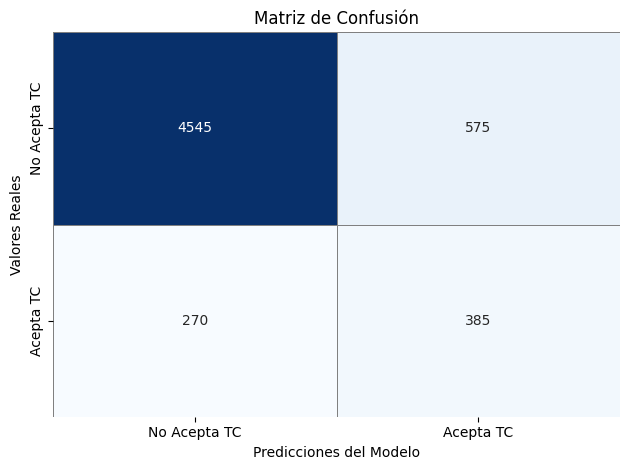

In [ ]:
#Matriz de confusión
matriz_confusion(best_tree, X_test, Y_test)

Evaluación de desempeño del modelo con los datos de prueba

In [ ]:
#Predecir resultados para datos de prueba
y_pred= best_tree.predict(X_test)

In [ ]:
print("Accuracy %s \n" %balanced_accuracy_score(Y_test, y_pred))
print("Roc %s \n" %roc_auc_score(Y_test, y_pred))
print("Recall %s \n" %recall_score(Y_test, y_pred))
print("F1 Score %s \n" %f1_score(Y_test, y_pred, average="binary"))
print("Precision %s \n" %precision_score(Y_test, y_pred))

Accuracy 0.7377407860209924 

Roc 0.7377407860209924 

Recall 0.5877862595419847 

F1 Score 0.4767801857585139 

Precision 0.4010416666666667 



- El modelo es capaz de 
- El modelo es capaz de 
- El modelo es capaz de 
- El modelo es capaz de 
- El modelo es capaz de 

Conclusión:


### Modelo 3

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Entrenamiento

In [ ]:
#Bosque Aleatorio
modelForest = RandomForestClassifier()

#Hiperparámetros
params= {
    'n_estimators': [100, 200, 500], #Número de árboles
    'criterion': ['gini', 'entropy'], #Función de calidad de la división
    'max_depth': [2, 4, 6, 8, 10], #Profundidad máxima del árbol
    'class_weight': [{0: 1, 1: w} for w in np.arange(1, 5)] #Pesos de las clases
}

#Métricas a utilizar
scoring= ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']

#Grid
grid_search= GridSearchCV(modelForest, params, scoring=scoring, refit='recall', n_jobs=-1, cv=10)
grid_search.fit(X_train, Y_train) #70%

#Mejor modelo e hiperparametros
best_forest = grid_search.best_estimator_

/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/metrics/_classification

In [ ]:
#Mejor modelo e hiperparametros
best_forest


RandomForestClassifier(class_weight={0: 1, 1: 4}, max_depth=8, n_estimators=500)

In [ ]:
#Mejores párametros
grid_search.best_params_

{'class_weight': {0: 1, 1: 4},
 'criterion': 'gini',
 'max_depth': 8,
 'n_estimators': 500}

Parámetros:
- 'n_estimators': número de árboles en el bosque aleatorio. 
- 'criterion': dicta la medida de calidad de una división
- 'max_depth': profundidad máxima del árbol, es decir, la cantidad máxima de niveles que puede tener el árbol.
- 'class_weight': asignar un peso a cada clase en la función de coste. 

Evaluación de desempeño del modelo con los datos de entrenamiento

In [ ]:
#Medida de evaluación del mejor modelo - entranamiento (train)
evaluation_metrics(grid_search)

,Mejor_Modelo
accuracy de la CV,0.873932
roc_auc de la CV,0.791428
recall de la CV,0.542634
f1 de la CV,0.489625
precision de la CV,0.446905


Evaluación

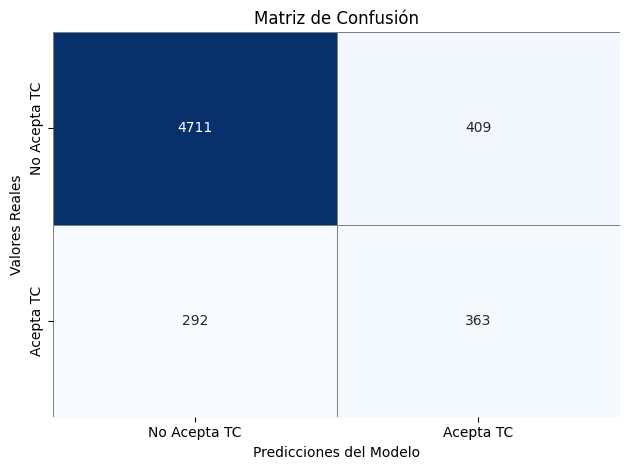

In [ ]:
#Matriz de confusión
matriz_confusion(best_forest, X_test, Y_test)

Evaluación de desempeño del modelo con los datos de prueba

In [ ]:
#Predecir resultados para datos de prueba
y_pred= best_forest.predict(X_test)

In [ ]:
print("Accuracy %s \n" %balanced_accuracy_score(Y_test, y_pred))
print("Roc %s \n" %roc_auc_score(Y_test, y_pred))
print("Recall %s \n" %recall_score(Y_test, y_pred))
print("F1 Score %s \n" %f1_score(Y_test, y_pred, average="binary"))
print("Precision %s \n" %precision_score(Y_test, y_pred))

Accuracy 0.7371578303912214 

Roc 0.7371578303912214 

Recall 0.5541984732824428 

F1 Score 0.508759635599159 

Precision 0.47020725388601037 



- El modelo es capaz de 
- El modelo es capaz de 
- El modelo es capaz de 
- El modelo es capaz de 
- El modelo es capaz de 

Conclusión:


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ed4e5f13-3af9-48d3-90dc-acc295659d32' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>